In [40]:
import pandas as pd
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent.resolve()))
from src.paths import *

## View topics distribution

In [41]:
from dataclasses import dataclass, field
from typing import Optional
import pandas as pd

@dataclass
class SubtopicStats:
    name: str
    count: int
    percentage: float  # percentage within parent topic

@dataclass
class TopicStats:
    name: str
    count: int
    percentage: float  # percentage of total posts
    subtopics: list[SubtopicStats] = field(default_factory=list)

@dataclass
class TopicsReport:
    total_posts: int
    total_topics: int
    total_unique_subtopics: int
    topics: list[TopicStats] = field(default_factory=list)

    def get_topic(self, name: str) -> Optional[TopicStats]:
        return next((t for t in self.topics if t.name == name), None)


def generate_topics_document(classified_path: str = VALIDATION_SAMPLE,
                             output_filename: str = 'topics_structure.txt') -> TopicsReport:

    df = pd.read_excel(classified_path)
    df = df[df['topic_veredict'] == True]
    df = df[df['subtopic_veredict'] == True]

    total_posts = len(df)
    topic_counts = df['topic'].value_counts()
    topic_percentages = (topic_counts / total_posts * 100).to_dict()
    sorted_topics = sorted(topic_percentages.items(), key=lambda x: x[1], reverse=True)

    report = TopicsReport(
        total_posts=total_posts,
        total_topics=len(sorted_topics),
        total_unique_subtopics=df['subtopics'].nunique()
    )

    lines = []
    lines.append("=" * 80)
    lines.append("TOPICS AND SUBTOPICS HIERARCHY")
    lines.append("=" * 80)
    lines.append("")

    for topic, topic_pct in sorted_topics:
        lines.append(f"{topic}: {topic_pct:.2f}% ({int(topic_counts[topic])} posts)")

        topic_posts = df[df['topic'] == topic]
        subtopic_counts = topic_posts['subtopics'].value_counts()
        subtopic_percentages = (subtopic_counts / len(topic_posts) * 100).to_dict()
        sorted_subtopics = sorted(subtopic_percentages.items(), key=lambda x: x[1], reverse=True)

        topic_stats = TopicStats(
            name=topic,
            count=int(topic_counts[topic]),
            percentage=topic_pct,
            subtopics=[
                SubtopicStats(
                    name=subtopic,
                    count=int(subtopic_counts[subtopic]),
                    percentage=subtopic_pct
                )
                for subtopic, subtopic_pct in sorted_subtopics
            ]
        )
        report.topics.append(topic_stats)

        for subtopic, subtopic_pct in sorted_subtopics:
            lines.append(f"  - {subtopic}: {subtopic_pct:.2f}% ({int(subtopic_counts[subtopic])} posts)")
        lines.append("")

    lines.append("")
    lines.append("=" * 80)
    lines.append("SUMMARY")
    lines.append("=" * 80)
    lines.append(f"Total posts: {report.total_posts}")
    lines.append(f"Total topics: {report.total_topics}")
    lines.append(f"Total unique subtopics: {report.total_unique_subtopics}")

    for l in lines:
        print(l)

    return report


report = generate_topics_document()

TOPICS AND SUBTOPICS HIERARCHY

OpenSSL installation/build and runtime errors: 14.15% (44 posts)
  - OpenSSL installation/build and linking (versions, packages, compilation): 81.82% (36 posts)
  - TLS/SSL runtime errors (certificates & connection issues): 11.36% (5 posts)
  - Key/certificate files and OpenSSL command usage: 6.82% (3 posts)

Encoding and byte/string conversions (Base64, binary): 11.90% (37 posts)
  - Byte/string/character encoding conversions (Base64, binary, hashes): 48.65% (18 posts)
  - Password hashing implementation and verification (MD5 and checks): 37.84% (14 posts)
  - Symmetric encryption/decryption errors (keys, padding, file/text decoding): 13.51% (5 posts)

X.509 certificates, signing, and trust chains: 8.36% (26 posts)
  - Private key & keystore management (PKCS#12, import/export/convert): 19.23% (5 posts)
  - Trust stores and certificate chain building/validation: 15.38% (4 posts)
  - Debugging certificate/crypto verification code errors: 15.38% (4 posts)


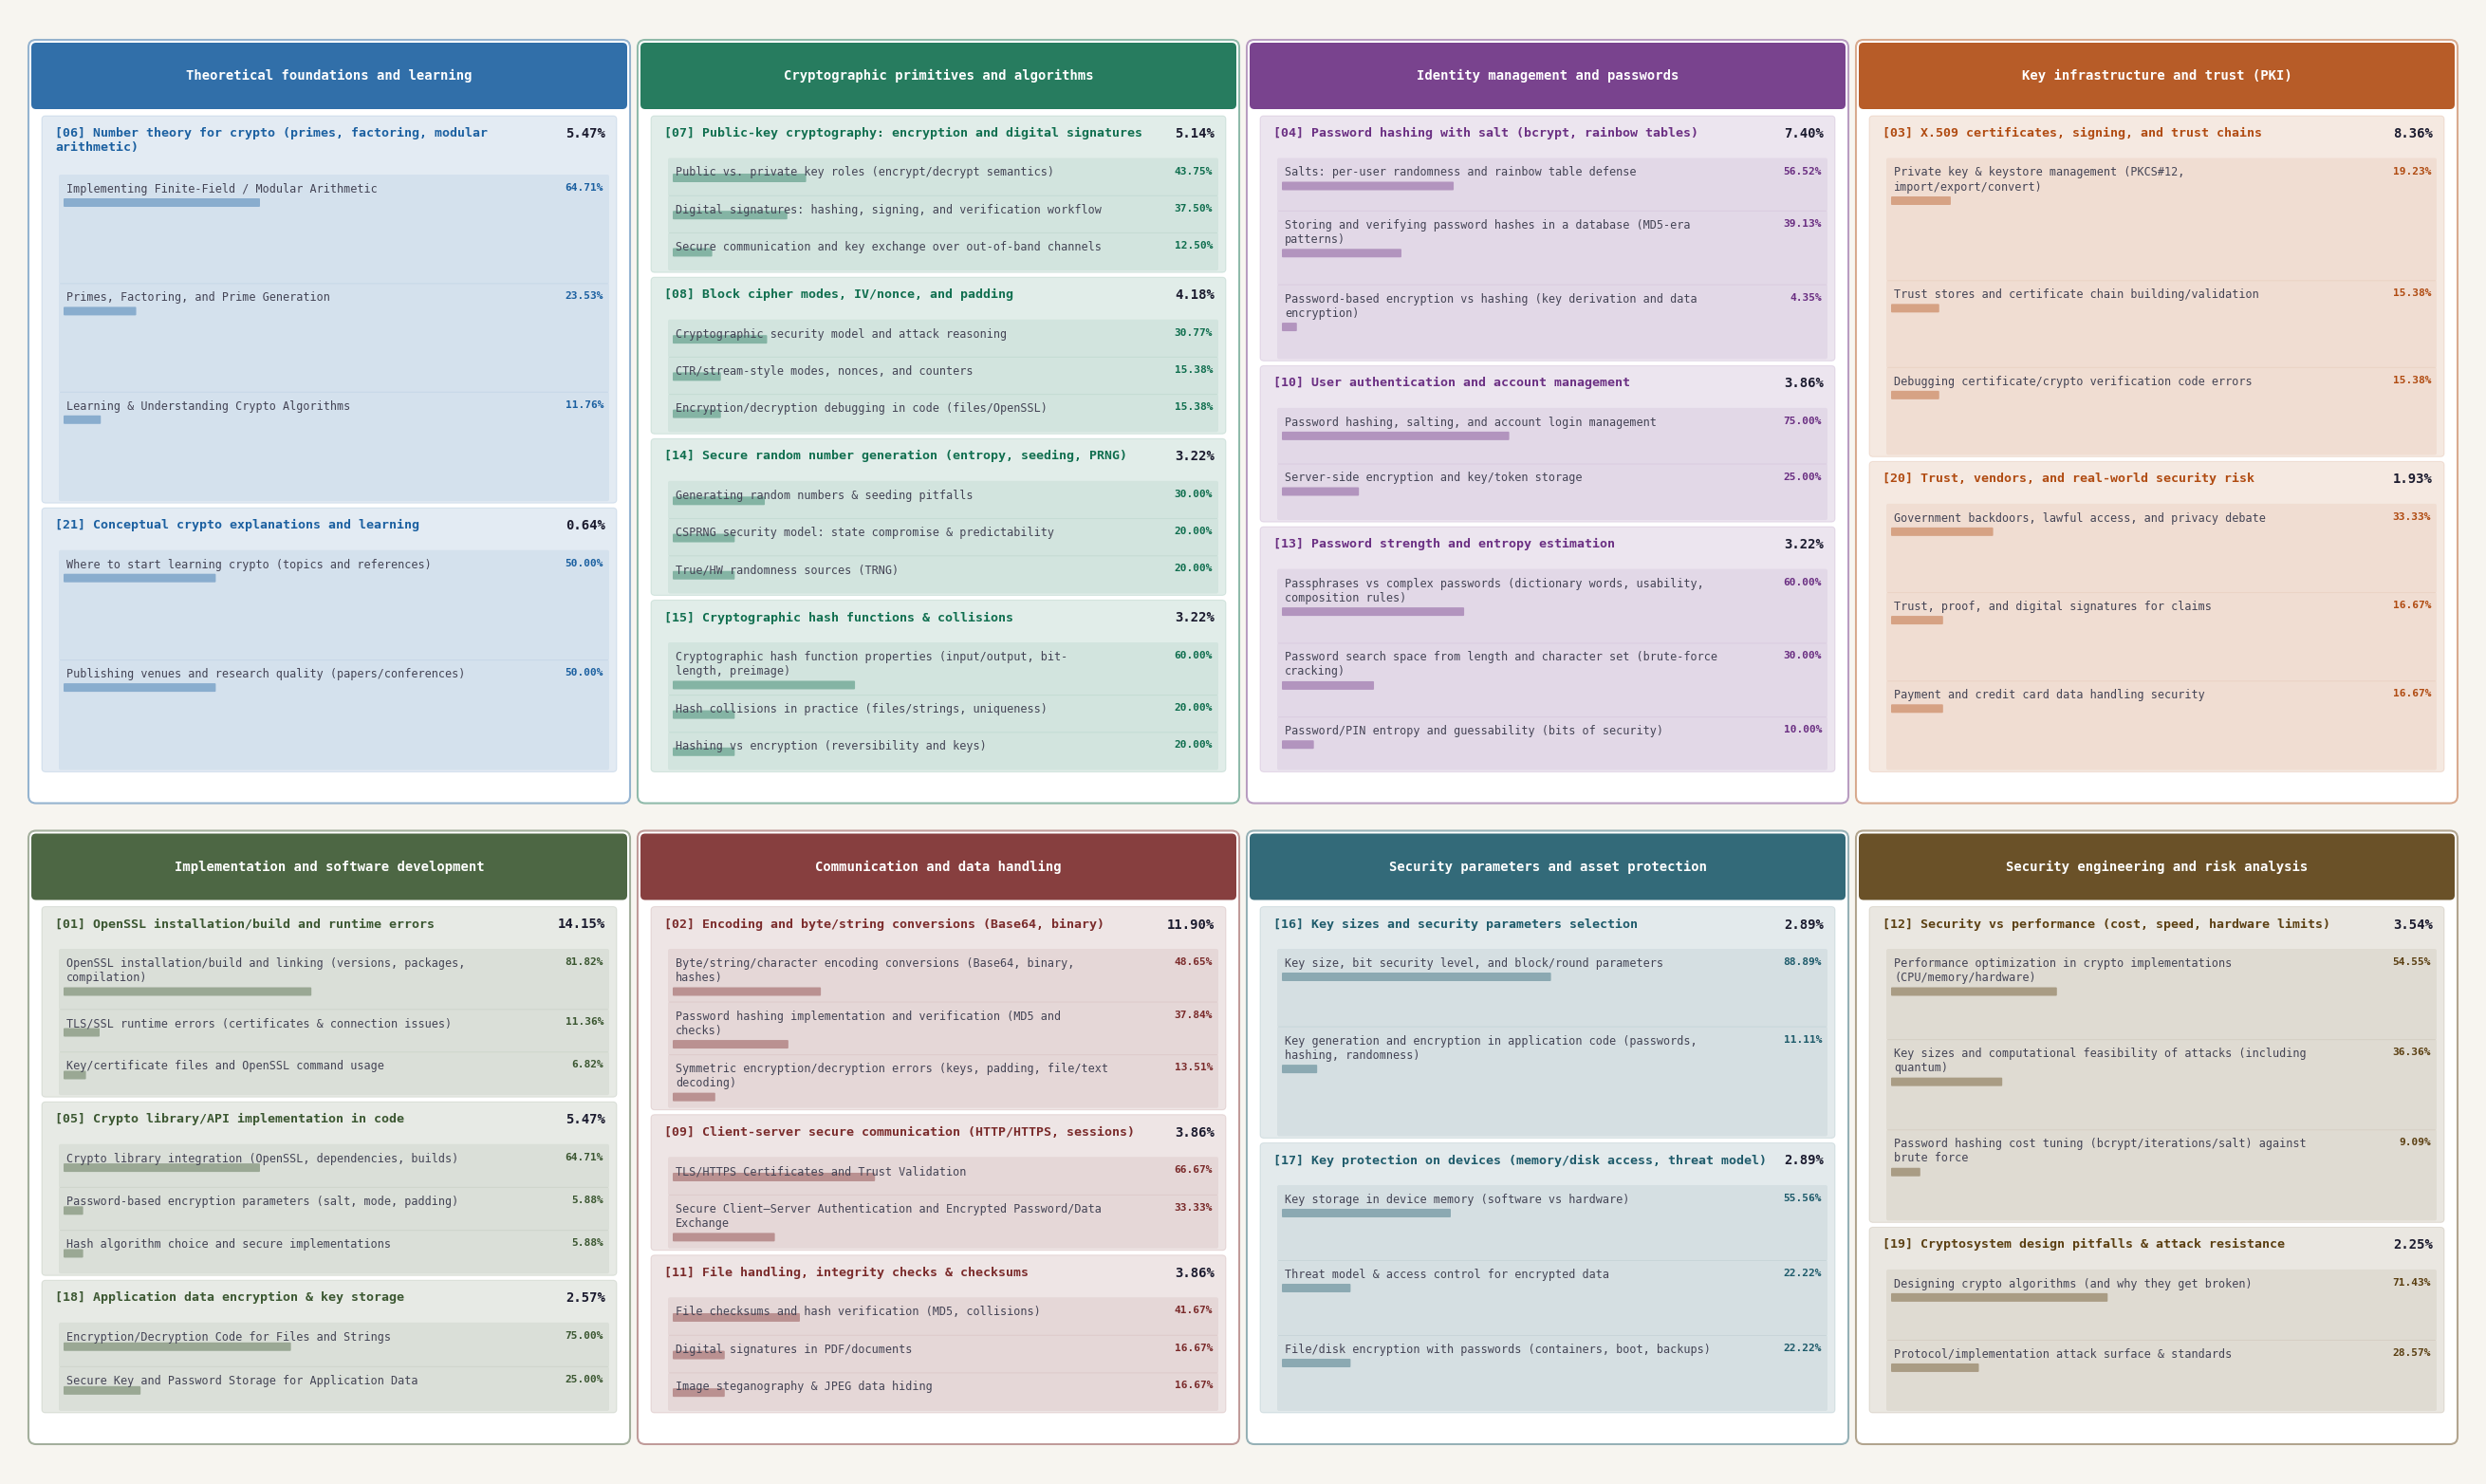

In [ ]:
                # Calculate estimated text height based on number of lines
                text_height = 0.10 + (nl - 1) * LINE_H_SUB if nl > 1 else 0.10
                text_height += 0.14  # padding after text to create gap
                
                # Proportional bar 
                bar_w = max((sub.percentage / 100) * sw * 0.55, 0.02)
                bar_h = 0.07
                
                # Smart bar positioning based on box height - with more spacing from text
                if sub_h > 0.50:  # large boxes
                    # Position bar well below text with more spacing
                    bar_y = sy + sub_h - text_height - 0.14
                elif sub_h > 0.35:  # medium boxes
                    # Position bar in lower area with good spacing
                    bar_y = sy + (sub_h * 0.36)  # slightly lower
                else:  # small boxes
                    # Center the bar with adequate spacing
                    bar_y = sy + (sub_h - bar_h) / 2 - 0.05
                
                ax.add_patch(FancyBboxPatch(
                    (sx + 0.04, bar_y), bar_w, bar_h,
                    boxstyle="round,pad=0.01",
                    facecolor=color, edgecolor="none", alpha=0.40, zorder=5))